# Step 2: Make your autoencoder

### Background
An autoencoder is a neural network that takes an input, encodes it into a lower-dimensional latent space through "encoding" layers, and then attempts to reconstruct the original input using "decoding" layers. Autoencoders are often used for dimensionality reduction.

### Your task
You will train a 64x16x64 autoencoder on the digits dataset. All of the following work should be done in a Jupyter Notebook.

### To-do
* Load the digits dataset through sklearn using sklearn.datasets.load_digits().
* Split the data into training and validation sets.
* Generate an instance of your NeuralNetwork class with a 64x16x64 autoencoder architecture.
* Train your autoencoder on the training data.
* Plot your training and validation loss by epoch.
* Quantify your average reconstruction error over the validation set.
* Explain why you chose the hyperparameter values you did.

## Initial imports

In [1]:
# import my NeuralNetwork class
from nn.nn import NeuralNetwork

# import sklearn utilities for data loading and splitting
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

# import numpy for calculations
import numpy as np

# import matplotlib for visualization
import matplotlib.pyplot as plt

## Load and split the Digits dataset

In [2]:
# load in the data
digits_dataset = load_digits()

# extract features and labels
X = digits_dataset.data
print(f"X shape: {X.shape}")

X shape: (1797, 64)


In [3]:
# split the data into training and validation sets
X_train, X_val = train_test_split(X, test_size=0.2, random_state=42)

# confirm data shapes are as expected
print(f"X_train shape: {X_train.shape}")
print(f"X_val shape: {X_val.shape}")

X_train shape: (1437, 64)
X_val shape: (360, 64)


## Create an instance of my NeuralNetwork class with a 64x16x64 autoencoder architecture

In [4]:
# define the model architecture and hyperparameters
nn_arch = [
    {'input_dim': 64, 'output_dim': 16, 'activation': 'relu'},
    {'input_dim': 16, 'output_dim': 64, 'activation': 'relu'}
]
lr = 1e-2
seed = 42
batch_size = 32
epochs = 500
loss_function = 'mse'

# create an instance of the autoencoder with the defined arguments
autoencoder = NeuralNetwork(
    nn_arch,
    lr,
    seed,
    batch_size,
    epochs,
    loss_function
)

## Train the autoencoder

In [5]:
# train the autoencoder and save the per eopch losses
per_epoch_loss_train, per_epoch_loss_val = autoencoder.fit(X_train, X_train, X_val, X_val)

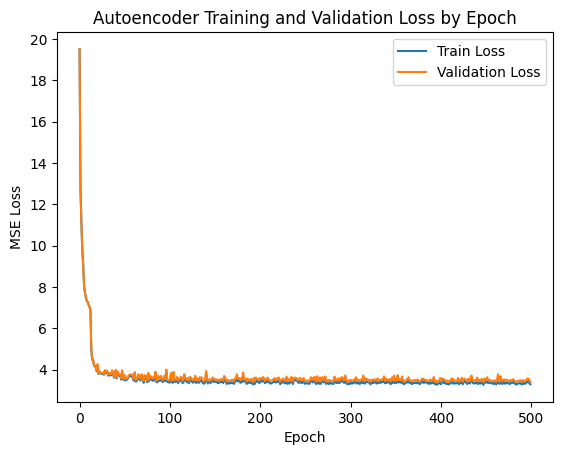

In [6]:
# display the training and validation losses by epoch
plt.plot(per_epoch_loss_train, label='Train Loss')
plt.plot(per_epoch_loss_val, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Autoencoder Training and Validation Loss by Epoch')
plt.legend()
plt.show()

## Quantify the average reconstruction error over the validation set

In [7]:
# compute the per image reconstruction error on the validation set
X_hat = autoencoder.predict(X_val)
reconstruction_errors = np.abs(X_hat - X_val)

# compute and display the mean reconstruction error
mean_reconstruction_error = np.mean(reconstruction_errors)
print(f"Absolute mean reconstruction error over the validation set: {mean_reconstruction_error:.4f}")

# compute and display the mean squared error
mse = np.mean((X_hat - X_val) ** 2)
print(f"Mean squared error over the validation set: {mse:.4f}")

Absolute mean reconstruction error over the validation set: 0.9989
Mean squared error over the validation set: 3.4307


## Explanation of hyperparameter selection

`nn_arch = [{'input_dim': 64, 'output_dim': 16, 'activation': 'relu'}, {'input_dim': 16, 'output_dim': 64, 'activation': 'relu'}]`: the network was initialized with a 64-D input layer, a 16-D hidden layer, and a 64-D output layer. Both layers utilize a ReLU activation function due to its computational efficiency and ability to produce low reconstruction errors compared to a sigmoid activation function. It is also more commonly used than binary cross entropy for autoencoder tasks.

`lr = 1e-2`: the selected learning rate appeared to achieve the lowerst validation loss when testing different hyperparameter values. Thus, it seems to effectively balance convergence speed and stability well during training.

`seed = 42`: this random seed was chosen to ensure reproducibility.

`batch_size = 32`: a batch size of 32 was selected to provide from tested hyperparameter values to balance the training stability with overall model accuracy.

`epochs = 500`: 500 epochs seemed like a safe choice, as the training loss seems to plateau around 100-200 epochs, thus 500 epochs should provide plenty of time to enable small optimizations.

`loss_function = 'mse'`: mean sqaured error was selected as the loss function because it is a common choice for image reconstruction tasks. Additionally, it makes more sense to use the mean squared error loss than binary cross entropy for an autoencoder, as the output is not binary. A loss function like binary cross entropy makes more sense for a classifier, but is not a good choice for an autoencoder.